## Load and pre-process MNIST digits for subsequent experiments

* Load as pytorch dataset
* Set up seed splitting function for reproducibility and repeat experiments
* Normalise pixel values to [0,1]
* 

### Load MNIST and pre-process
* Load torch dataset
* Default train/test split
* Transform to 28x28 pixels, normalise to {0,1} pixel values

train: 60000 images | test: 10000 images


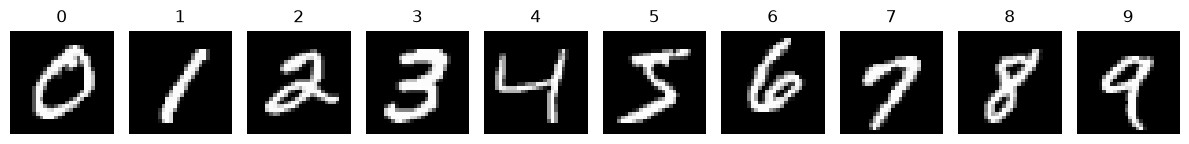

In [1]:
# Cell 1 — Load MNIST and take a look
# needs: torch, torchvision, matplotlib  (downloads MNIST once on first run)
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# ToTensor() -> float image in [0,1], shape [1,28,28]   <-- the pixel-scaling decision lives here
tfm = transforms.ToTensor()
train = datasets.MNIST(root="./data", train=True,  download=True, transform=tfm)
test  = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)
print(f"train: {len(train)} images | test: {len(test)} images")

# Peek: one example of each digit 0-9
seen = {}
for img, label in train:
    seen.setdefault(label, img)
    if len(seen) == 10:
        break
fig, axes = plt.subplots(1, 10, figsize=(12, 1.6))
for d in range(10):
    axes[d].imshow(seen[d].squeeze(), cmap="gray")
    axes[d].set_title(str(d)); axes[d].axis("off")
plt.tight_layout(); plt.show()

#### Split labels

* Divide dataset into 5 pairs
* Based on seed for reproducibility

In [2]:
# Cell 2 — Seeded digit-pair splitter (pairing + per-context indices)
import numpy as np

def make_pairing(seed=None):
    """Assign the 10 digits to 5 ordered contexts of 2 digits each.
    seed=None -> canonical {0,1},{2,3},...,{8,9};  int -> reproducible random."""
    digits = list(range(10))
    if seed is not None:
        digits = np.random.default_rng(seed).permutation(digits).tolist()
    return {c: (digits[2*c], digits[2*c + 1]) for c in range(5)}

def context_indices(dataset, contexts):
    """Indices into `dataset` for each context. Call once with train, once with test."""
    targets = dataset.targets.numpy()
    return {c: np.where(np.isin(targets, pair))[0] for c, pair in contexts.items()}

# Look at one example pairing (uses `train`/`test` from Cell 1)
contexts = make_pairing(seed=0)
print("seed=0 pairing:", contexts)

train_idx = context_indices(train, contexts)
test_idx  = context_indices(test,  contexts)
for c in range(5):
    print(f"context {c} = {contexts[c]}:  train={len(train_idx[c])}  test={len(test_idx[c])}")

seed=0 pairing: {0: (4, 6), 1: (2, 7), 2: (3, 5), 3: (9, 0), 4: (8, 1)}
context 0 = (4, 6):  train=11760  test=1940
context 1 = (2, 7):  train=12223  test=2060
context 2 = (3, 5):  train=11552  test=1902
context 3 = (9, 0):  train=11872  test=1989
context 4 = (8, 1):  train=12593  test=2109


#### Check split

context 0 = (4, 6) | shape (1, 28, 28) | range [0.00, 1.00] | sample labels [4, 4, 6, 6, 4, 4, 6, 6]


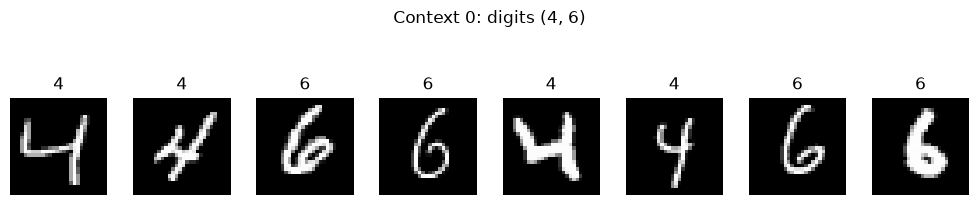

context 1 = (2, 7) | shape (1, 28, 28) | range [0.00, 1.00] | sample labels [2, 7, 2, 2, 2, 7, 7, 7]


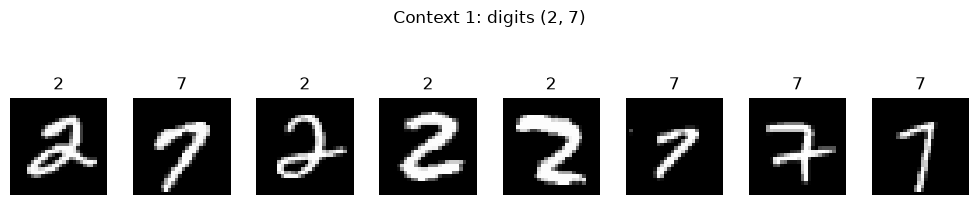

context 2 = (3, 5) | shape (1, 28, 28) | range [0.00, 1.00] | sample labels [5, 3, 3, 5, 3, 3, 3, 5]


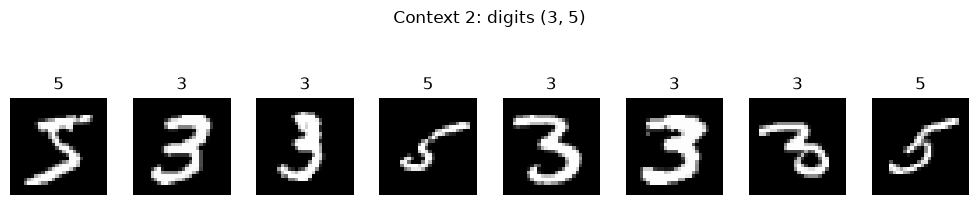

context 3 = (9, 0) | shape (1, 28, 28) | range [0.00, 1.00] | sample labels [0, 9, 9, 0, 9, 9, 0, 0]


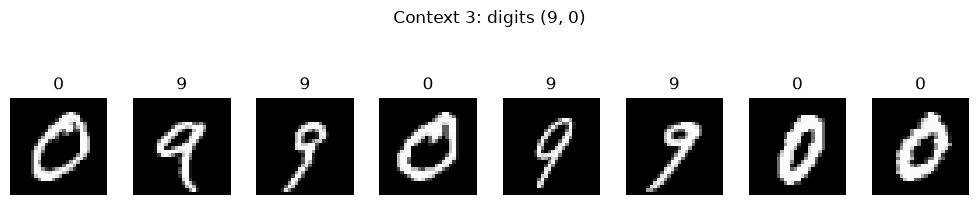

context 4 = (8, 1) | shape (1, 28, 28) | range [0.00, 1.00] | sample labels [1, 1, 1, 1, 8, 1, 1, 8]


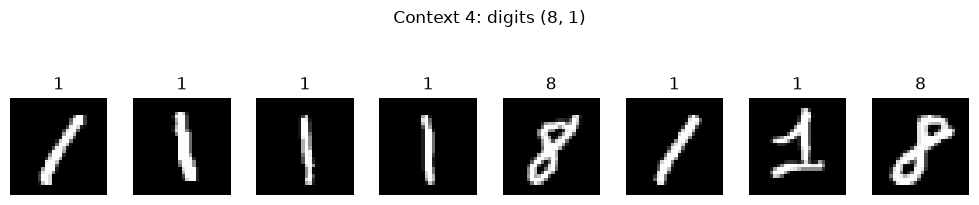

In [3]:
# Cell 3 — Sanity-check one context: right digits? right shape & range?
for c in range(5):
# c = 0  # which context to inspect
    pair = contexts[c]

    # Grab the first few TRAIN images from this context
    idxs = train_idx[c][:8]
    imgs   = [train[i][0] for i in idxs]   # each: tensor [1,28,28]
    labels = [train[i][1] for i in idxs]   # global digit (0-9)

    # Shape & range checks (these will throw loudly if something is off)
    x0 = imgs[0]
    assert tuple(x0.shape) == (1, 28, 28), f"unexpected shape {tuple(x0.shape)}"
    assert 0.0 <= x0.min().item() and x0.max().item() <= 1.0, "pixels not in [0,1]"
    assert set(labels).issubset(set(pair)), f"found labels outside {pair}: {labels}"
    print(f"context {c} = {pair} | shape {tuple(x0.shape)} | "
        f"range [{x0.min():.2f}, {x0.max():.2f}] | sample labels {labels}")

    # Look at them
    fig, axes = plt.subplots(1, 8, figsize=(10, 1.6))
    for ax, img, lab in zip(axes, imgs, labels):
        ax.imshow(img.squeeze(), cmap="gray")
        ax.set_title(str(lab)); ax.axis("off")
    fig.suptitle(f"Context {c}: digits {pair}", y=1.25)
    plt.tight_layout(); plt.show()

### Test network configurations

#### Set up train/eval funcitons
* One hidden layer (for later interpretability - map to 2d image)
* 10 output classes

In [4]:
# Cell 4 — A configurable MLP + reusable train / eval loops
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

def make_mlp(hidden=(128,), in_dim=784, out_dim=10):
    """Flatten -> [Linear, ReLU] per hidden size -> Linear.  hidden=() => plain linear classifier."""
    layers, prev = [nn.Flatten()], in_dim
    for h in hidden:
        layers += [nn.Linear(prev, h), nn.ReLU()]
        prev = h
    layers += [nn.Linear(prev, out_dim)]
    return nn.Sequential(*layers)

def fit(model, loader, epochs=5, lr=0.1, optim='adam'):          # SGD default; was Adam lr=1e-3
    model.to(device).train()
    if optim == 'sgd':
        opt = torch.optim.SGD(model.parameters(), lr=0.1)
    elif optim == 'adam':
        opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    for ep in range(epochs):
        running = 0.0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward(); opt.step()
            running += loss.item() * x.size(0)
        print(f"  epoch {ep+1}/{epochs}  train loss {running/len(loader.dataset):.4f}")
    return model

@torch.no_grad()
def evaluate(model, loader):
    model.to(device).eval()
    correct = total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        correct += (model(x).argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total

device: cpu


In [5]:
# Cell 5 — Joint baseline: train on ALL 10 digits at once -> our ceiling
torch.manual_seed(0)  # reproducible init + shuffling

train_loader = DataLoader(train, batch_size=128, shuffle=True)
test_loader  = DataLoader(test,  batch_size=512, shuffle=False)

joint = make_mlp(hidden=(128,))          # <-- the depth/width decision lives on this line
print(f"params: {sum(p.numel() for p in joint.parameters()):,}")

fit(joint, train_loader, epochs=5)        # was: train(...)
acc = evaluate(joint, test_loader)
print(f"\nJOINT reference accuracy (1 hidden layer x128): {acc*100:.2f}%")

params: 101,770
  epoch 1/5  train loss 0.4125
  epoch 2/5  train loss 0.1958
  epoch 3/5  train loss 0.1436
  epoch 4/5  train loss 0.1110
  epoch 5/5  train loss 0.0892

JOINT reference accuracy (1 hidden layer x128): 97.12%


#### Sweep hidden layer width
* Single hidden layer vs 2 hidden layers
* Sizes 16 to 400, swuare numbers

  epoch 1/5  train loss 0.6705
  epoch 2/5  train loss 0.3609
  epoch 3/5  train loss 0.3188
  epoch 4/5  train loss 0.2991
  epoch 5/5  train loss 0.2879
  epoch 1/5  train loss 0.6893
  epoch 2/5  train loss 0.3118
  epoch 3/5  train loss 0.2680
  epoch 4/5  train loss 0.2437
  epoch 5/5  train loss 0.2264
  epoch 1/5  train loss 0.5861
  epoch 2/5  train loss 0.2778
  epoch 3/5  train loss 0.2319
  epoch 4/5  train loss 0.2001
  epoch 5/5  train loss 0.1758
  epoch 1/5  train loss 0.4803
  epoch 2/5  train loss 0.2398
  epoch 3/5  train loss 0.1871
  epoch 4/5  train loss 0.1531
  epoch 5/5  train loss 0.1291
  epoch 1/5  train loss 0.4125
  epoch 2/5  train loss 0.1958
  epoch 3/5  train loss 0.1436
  epoch 4/5  train loss 0.1110
  epoch 5/5  train loss 0.0892
  epoch 1/5  train loss 0.3669
  epoch 2/5  train loss 0.1623
  epoch 3/5  train loss 0.1106
  epoch 4/5  train loss 0.0822
  epoch 5/5  train loss 0.0643
  epoch 1/5  train loss 0.3285
  epoch 2/5  train loss 0.1368
  epoch 

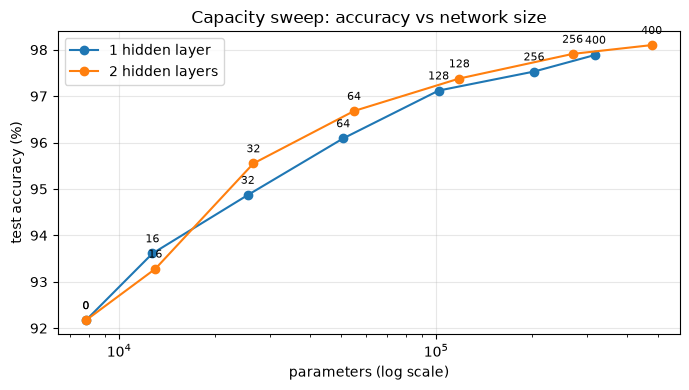

In [6]:
# Capacity sweep: 1-layer vs 2-layer, same axes
import matplotlib.pyplot as plt
sweeps = {
    "1 hidden layer":  [(), (16,), (32,), (64,), (128,), (256,), (400,)],
    "2 hidden layers": [(), (16,16), (32,32), (64,64), (128,128), (256,256), (400,400)],
}
plt.figure(figsize=(7, 4))
for label, widths in sweeps.items():
    pts = []
    for h in widths:
        torch.manual_seed(0)
        model = make_mlp(hidden=h)
        n_params = sum(p.numel() for p in model.parameters())
        fit(model, train_loader, epochs=5)
        pts.append((n_params, evaluate(model, test_loader) * 100, h[0] if h else 0))
    ps, accs, ws = zip(*pts)
    plt.plot(ps, accs, "o-", label=label)
    for p, a, w in pts:
        plt.annotate(str(w), (p, a), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
plt.xscale("log"); plt.xlabel("parameters (log scale)"); plt.ylabel("test accuracy (%)")
plt.title("Capacity sweep: accuracy vs network size"); plt.legend()
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

#### Outcome
* 1 hidden layer is sufficient (0.3% improvement from 2 layers, with huge interpretablity cost)
* Elbow around 128
* Will proceed with 1 layer of sizes
    * 64: Tight (≈51k params, 96.1%): forces feature reuse, so interference will be visible.
    * 256: Roomy (≈204k params, 97.5%): room to spare, so we can watch whether extra capacity reduces forgetting.

### Split MNIST experiment
* 5 pairs of random digits
* Binary shared head - 0,1 output, same head for each new task
* Initially 64 hidden units
* No optimiser (Adam momentum) reset
* 2 rounds for each pair

In [7]:
# Cell 7 — Stage 2 engine: sequential trainer with all-pair logging (shared 2-unit head)
import numpy as np
from torch.utils.data import Subset, DataLoader
import torch.nn as nn

# Build each context's TEST set once (within-pair labels: pair[0]->0, pair[1]->1)
def build_context_testsets():
    X, y = {}, {}
    for c in range(5):
        idx = test_idx[c]
        X[c] = torch.stack([test[i][0] for i in idx]).to(device)
        yg = torch.tensor([test[i][1] for i in idx])
        y[c] = (yg == contexts[c][1]).long().to(device)
    return X, y

Xtest_c, ytest_c = build_context_testsets()
print("per-context test sizes:", {c: len(ytest_c[c]) for c in range(5)})

@torch.no_grad()
def eval_pair(model, c):
    """Accuracy on context c's test set, via the shared 2-unit head."""
    model.eval()
    acc = (model(Xtest_c[c]).argmax(1) == ytest_c[c]).float().mean().item()
    model.train()
    return acc

def run_sequential(model, sequence, iters_per_task=200, eval_every=20,
                   lr=1e-3, batch_size=128):
    """Train `model` on each context in `sequence`, one at a time (shared 2-unit head,
    within-pair labels). Logs accuracy on ALL 5 pairs every `eval_every` steps.
    One optimiser across the whole run (no reset).
    Reproducibility: seed once before building the model (see Cell 8)."""
    model.to(device).train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    log = [{"step": 0, "phase": -1, "train_c": None,           # snapshot before any training
            "accs": [eval_pair(model, k) for k in range(5)]}]
    step = 0
    for phase, c in enumerate(sequence):
        loader = DataLoader(Subset(train, train_idx[c].tolist()),
                            batch_size=batch_size, shuffle=True)
        it = iter(loader)
        for _ in range(iters_per_task):
            try:    x, yg = next(it)
            except StopIteration:
                    it = iter(loader); x, yg = next(it)
            x = x.to(device)
            y = (yg == contexts[c][1]).long().to(device)        # within-pair labels
            opt.zero_grad(); loss_fn(model(x), y).backward(); opt.step()
            step += 1
            if step % eval_every == 0:
                log.append({"step": step, "phase": phase, "train_c": c,
                            "accs": [eval_pair(model, k) for k in range(5)]})
    return log

per-context test sizes: {0: 1940, 1: 2060, 2: 1902, 3: 1989, 4: 2109}


In [8]:
# Cell 8 — Two rounds over the 5 pairs (tight net, width 64); accuracy on ALL pairs
sequence = [0, 1, 2, 3, 4]*5                        # two passes through the pairs
print("sequence:", sequence)                        
iters_per_task, eval_every = 200, 20

torch.manual_seed(0)                                # fixes init AND the shuffle stream
model = make_mlp(hidden=(64,), out_dim=2)           # shared 2-unit head; tight net
log = run_sequential(model, sequence, iters_per_task=iters_per_task, eval_every=eval_every)


sequence: [0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4]


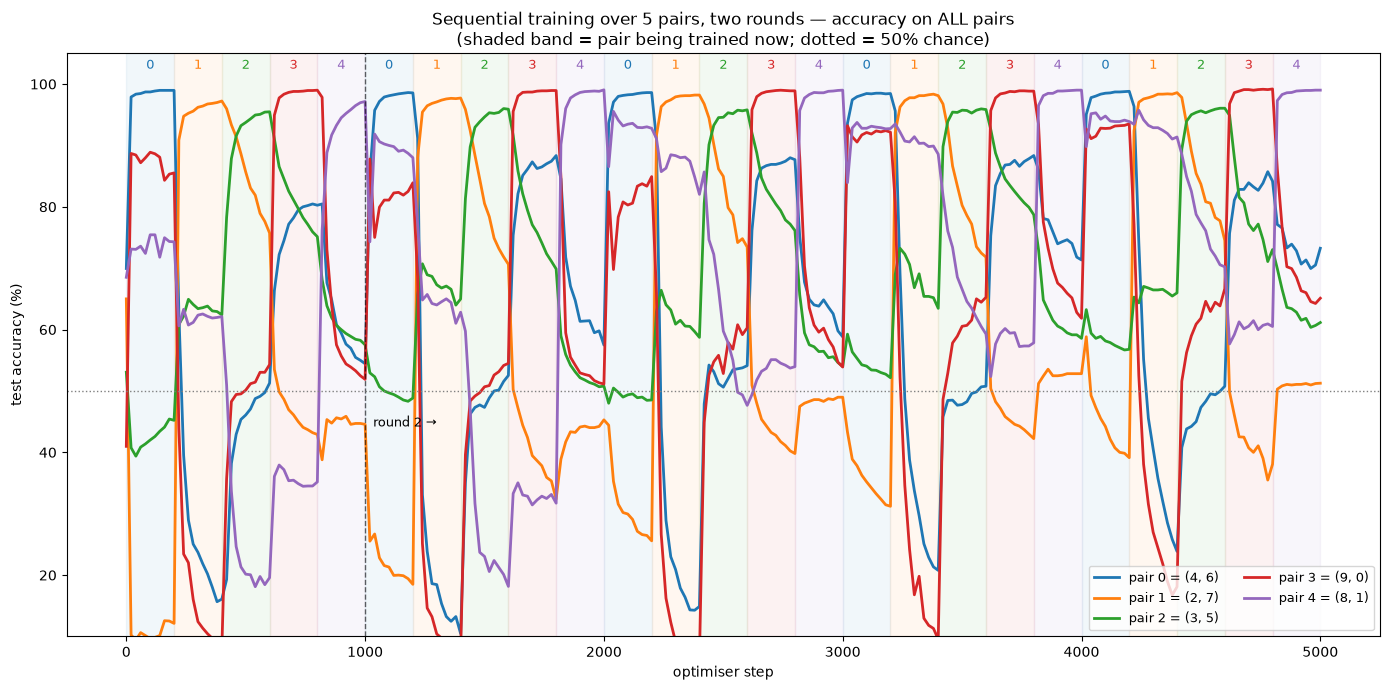

In [9]:

steps = [e["step"] for e in log]
accs  = np.array([e["accs"] for e in log])          # [n_evals, 5]
fig, ax = plt.subplots(figsize=(14, 7))
colors = plt.cm.tab10(np.arange(5))
for k in range(5):
    ax.plot(steps, accs[:, k]*100, color=colors[k], lw=2, label=f"pair {k} = {contexts[k]}")

bounds = [i*iters_per_task for i in range(len(sequence)+1)]
for phase, c in enumerate(sequence):                # shade the pair being trained, label it on top
    ax.axvspan(bounds[phase], bounds[phase+1], color=colors[c], alpha=0.06)
    ax.text((bounds[phase]+bounds[phase+1])/2, 102, str(c), ha="center", va="bottom",
            color=colors[c], fontsize=9)
ax.axvline(bounds[5], color="k", ls="--", lw=1, alpha=0.6)
ax.text(bounds[5], 46, "  round 2 \u2192", fontsize=9, va="top")
ax.axhline(50, color="gray", ls=":", lw=1)          # 2-way chance

ax.set_xlabel("optimiser step"); ax.set_ylabel("test accuracy (%)"); ax.set_ylim(10, 105)
ax.set_title("Sequential training over 5 pairs, two rounds — accuracy on ALL pairs\n"
             "(shaded band = pair being trained now; dotted = 50% chance)")
ax.legend(loc="lower right", ncol=2, fontsize=9)
plt.tight_layout(); plt.show()

#### Outcome
These are driven by the plot, and they're deliberately provisional, because part of what the plot shows isn't what it looks like:

* Forgetting is real and reproduced. Every pair hits ~99% inside its own training band and decays once other pairs are trained — with no anti-forgetting mechanism, on an easy toy. This is the "none" lower-target behaviour the field warns about.
* But raw accuracy overstates it. Any line below 50% on a balanced 2-way test (red/pair 3 plunging to ~15–20%) cannot be forgetting — a forgotten pair drifts toward 50%, not under it. Those dives are the shared head's output polarity getting overwritten while the features still separate the pair. An unknown fraction of the visible "collapse" is measurement artifact, not lost knowledge.
* The red↔green swings are mostly that artifact. Training pair 2 (9,5) reorganises the very output units pair 3 (3,4) reads from, flipping its sign. It is not yet evidence that those digits are specially confusable.
* Your "yellow & red retained, blue & green plateau lower" is a real pattern in this run — but with one seed plus the polarity confound, we can't say whether it's genuine pair difficulty or feature-overlap luck. Hypothesis, not result.
* Relearning is fast across rounds (warm features) but forgetting doesn't visibly shrink round-over-round → no consolidation, exactly as expected without a CL mechanism.
* A faint "rising floor" (some pairs above 50% before their first band) hints at shared features doing incidental work, but it's weak and confounded — the probe is the clean test.
* Bottom line: the run did its job, but it tangles three things together — true forgetting, head-polarity artifacts, and pair-specific feature correlations. Separating them is precisely what the next setup does.

### One head per pair (Task-IL) and Linear probe

In [10]:
# Cell 9 — Sound harness: shared trunk + per-pair heads, plus a linear probe
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import Subset, DataLoader
from sklearn.linear_model import LogisticRegression   # pip install scikit-learn if missing

class MultiHeadMLP(nn.Module):
    """Shared trunk (the representation) + one 2-unit head per pair (Task-IL)."""
    def __init__(self, hidden=64, n_pairs=5, in_dim=784):
        super().__init__()
        self.trunk = nn.Sequential(nn.Flatten(), nn.Linear(in_dim, hidden), nn.ReLU())
        self.heads = nn.ModuleList([nn.Linear(hidden, 2) for _ in range(n_pairs)])
    def features(self, x):           # the representation the probe reads (frozen)
        return self.trunk(x)
    def forward(self, x, head):      # classify pair `head` via its own output units
        return self.heads[head](self.trunk(x))

def _stack(dataset, idx):
    return torch.stack([dataset[i][0] for i in idx]).to(device)

# Fixed eval data per context: test sets (heads + probe eval) and a probe-train subsample
PROBE_N = 2000
Xtest_c, ytest_c, Xprobe_c, yprobe_c = {}, {}, {}, {}
for c in range(5):
    ti = test_idx[c]
    Xtest_c[c]  = _stack(test, ti)
    ytest_c[c]  = torch.tensor([1 if test[i][1]==contexts[c][1] else 0 for i in ti]).to(device)
    pi = train_idx[c][:PROBE_N]
    Xprobe_c[c] = _stack(train, pi)
    yprobe_c[c] = np.array([1 if train[i][1]==contexts[c][1] else 0 for i in pi])
print("ready: per-context test + probe sets")

@torch.no_grad()
def _feats(model, X):
    model.eval(); f = model.features(X).cpu().numpy(); model.train()
    return f

@torch.no_grad()
def eval_head(model, c):
    """Stale-head accuracy on pair c: head c reading the CURRENT (possibly drifted) trunk."""
    model.eval()
    a = (model(Xtest_c[c], c).argmax(1) == ytest_c[c]).float().mean().item()
    model.train(); return a

def probe_within(model, c):
    """Linear decodability of pair c from the CURRENT trunk: fresh readout, scored on test."""
    clf = LogisticRegression(max_iter=200)
    clf.fit(_feats(model, Xprobe_c[c]), yprobe_c[c])
    return clf.score(_feats(model, Xtest_c[c]), ytest_c[c].cpu().numpy())

ready: per-context test + probe sets


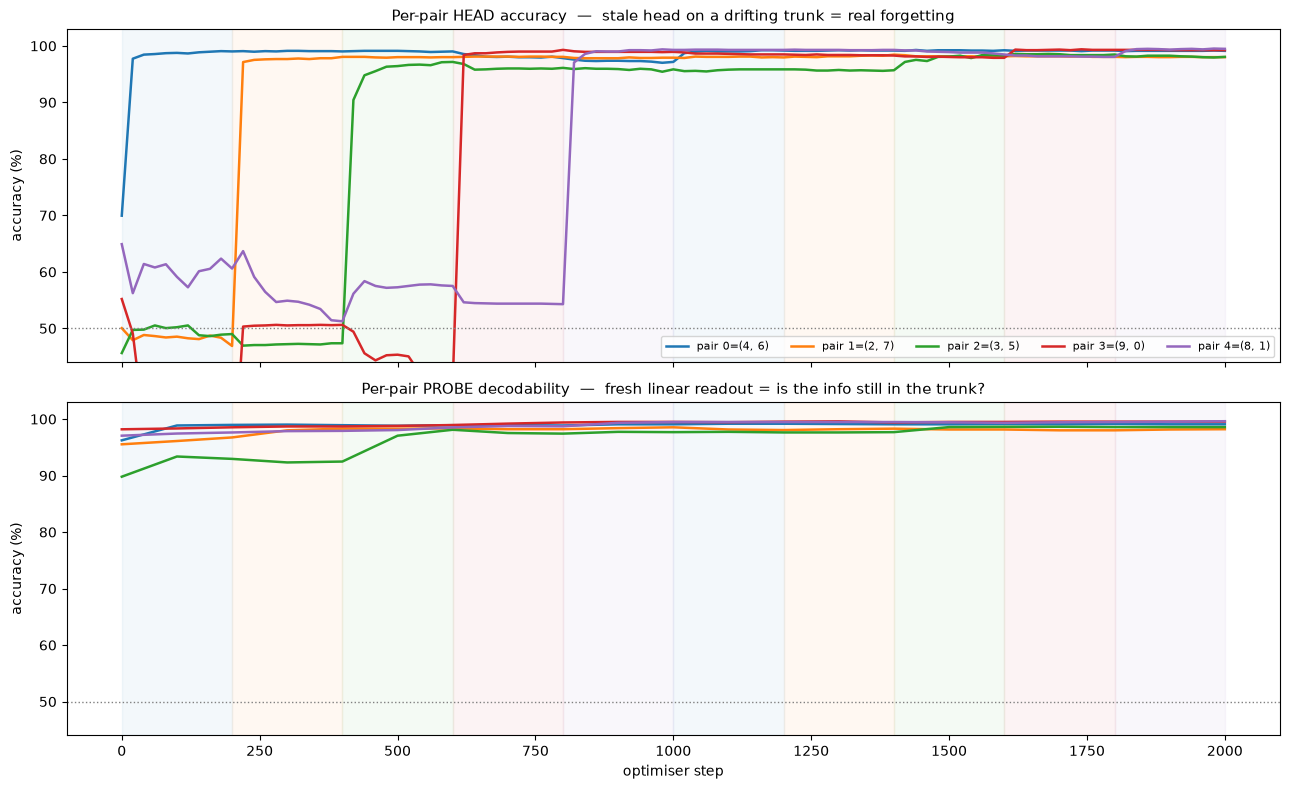

In [11]:
# Cell 10 — Sound sequential run + the two-panel diagnostic
def run_sound(model, sequence, iters_per_task=200, eval_every=20, probe_every=100,
              lr=1e-3, batch_size=128):
    model.to(device).train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    head_log = [(0, [eval_head(model, k)    for k in range(5)])]
    probe_log = [(0, [probe_within(model, k) for k in range(5)])]
    step = 0
    for c in sequence:
        loader = DataLoader(Subset(train, train_idx[c].tolist()), batch_size=batch_size, shuffle=True)
        it = iter(loader)
        for _ in range(iters_per_task):
            try: x, yg = next(it)
            except StopIteration: it = iter(loader); x, yg = next(it)
            x = x.to(device); y = (yg == contexts[c][1]).long().to(device)
            opt.zero_grad(); loss_fn(model(x, c), y).backward(); opt.step()
            step += 1
            if step % eval_every  == 0: head_log.append((step,  [eval_head(model, k)    for k in range(5)]))
            if step % probe_every == 0: probe_log.append((step, [probe_within(model, k) for k in range(5)]))
    return {"head": head_log, "probe": probe_log}

# Run one seed on the tight net, 5 rounds (directly comparable to your earlier plot)
rounds, iters_per_task = 2, 200
sequence = [0,1,2,3,4] * rounds

torch.manual_seed(0)
model = MultiHeadMLP(hidden=64)
out = run_sound(model, sequence, iters_per_task=iters_per_task)   # ~1-2 min; probes cost most

hs, ha = zip(*out["head"]);  ha = np.array(ha)*100
ps, pa = zip(*out["probe"]); pa = np.array(pa)*100
colors = plt.cm.tab10(np.arange(5))
bounds = [i*iters_per_task for i in range(len(sequence)+1)]

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for ax, S, A, ttl in [
    (axes[0], hs, ha, "Per-pair HEAD accuracy  —  stale head on a drifting trunk = real forgetting"),
    (axes[1], ps, pa, "Per-pair PROBE decodability  —  fresh linear readout = is the info still in the trunk?")]:
    for k in range(5):
        ax.plot(S, A[:, k], color=colors[k], lw=1.8, label=f"pair {k}={contexts[k]}")
    for ph, c in enumerate(sequence):
        ax.axvspan(bounds[ph], bounds[ph+1], color=colors[c], alpha=0.05)
    ax.axhline(50, color="gray", ls=":", lw=1); ax.set_ylim(44, 103); ax.set_ylabel("accuracy (%)")
    ax.set_title(ttl, fontsize=11)
axes[0].legend(loc="lower right", ncol=5, fontsize=8); axes[1].set_xlabel("optimiser step")
plt.tight_layout(); plt.show()

#### Outcome
* High linear probe accuracy. The linear probe is unaffected by retraining. Suggests that features required for all pairs are learned early in the hidden layer and never forgotten
* High head accuracy. Each head learns once, and never forgets.
* Together, suggests that the problem is too simple to demonstrate forgetting.

### Pivot to single output Class-IL task

In [12]:
# Cell 11 — Class-IL engine: single 10-way head, global digit labels
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import Subset, DataLoader

def _stack(dataset, idx):
    return torch.stack([dataset[i][0] for i in idx]).to(device)

# Per-task TEST sets with GLOBAL digit labels (0-9) -- built once
ci_Xtest, ci_ytest = {}, {}
for c in range(5):
    ti = test_idx[c]
    ci_Xtest[c] = _stack(test, ti)
    ci_ytest[c] = torch.tensor([test[i][1] for i in ti]).to(device)   # global digit label
print("Class-IL test sets ready:", {c: len(ci_ytest[c]) for c in range(5)})

@torch.no_grad()
def eval_task(model, c):
    """Accuracy on task c's test set, predicting over ALL 10 digits (no task hint)."""
    model.eval()
    a = (model(ci_Xtest[c]).argmax(1) == ci_ytest[c]).float().mean().item()
    model.train()
    return a

def run_classil(model, sequence, iters_per_task=200, eval_every=20, optim='adam', lr=1e-3, batch_size=128):
    """Train on each task in `sequence` one at a time: single 10-way head, global labels,
    no anti-forgetting mechanism ('none' baseline). One optimiser, no reset.
    Logs accuracy on all 5 tasks every `eval_every` steps."""
    model.to(device).train()
    if optim == 'sgd':
        opt = torch.optim.SGD(model.parameters(), lr=0.1)
    elif optim == 'adam':
        opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    log = [(0, [eval_task(model, k) for k in range(5)])]
    step = 0
    for c in sequence:
        loader = DataLoader(Subset(train, train_idx[c].tolist()), batch_size=batch_size, shuffle=True)
        it = iter(loader)
        for _ in range(iters_per_task):
            try: x, y = next(it)
            except StopIteration: it = iter(loader); x, y = next(it)
            x, y = x.to(device), y.to(device)          # y = global digit label, used directly
            opt.zero_grad(); loss_fn(model(x), y).backward(); opt.step()
            step += 1
            if step % eval_every == 0:
                log.append((step, [eval_task(model, k) for k in range(5)]))
    return log

Class-IL test sets ready: {0: 1940, 1: 2060, 2: 1902, 3: 1989, 4: 2109}


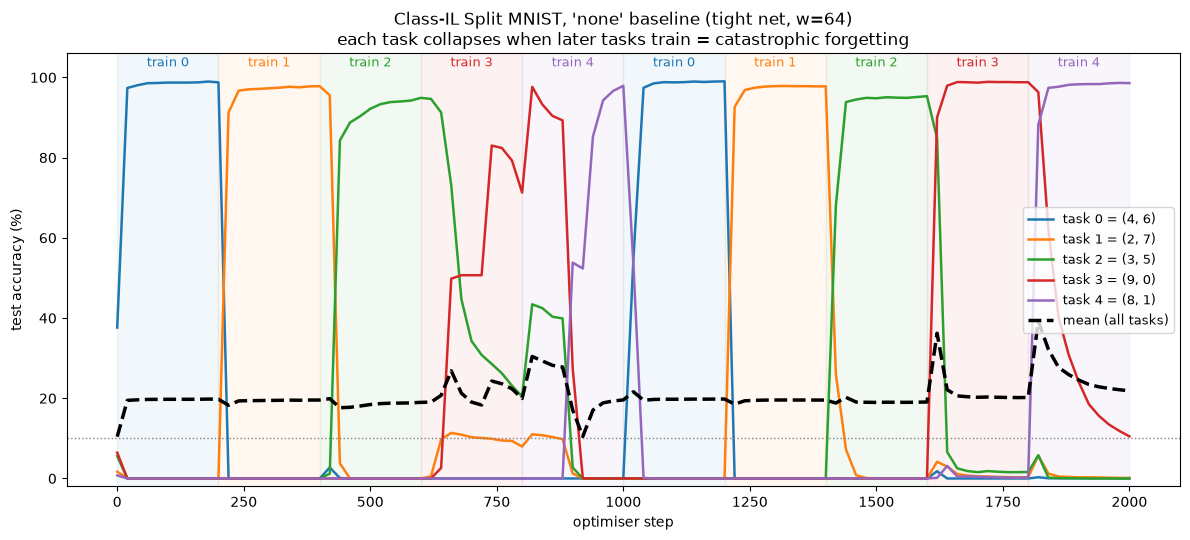

final mean accuracy (all 5 tasks): 21.8%   [chance 10%, joint ceiling ~96%]


In [13]:
# Cell 12 — Class-IL 'none' baseline (tight net) and the forgetting staircase
sequence = [0, 1, 2, 3, 4] * 2            # one pass through the five tasks
iters_per_task, eval_every = 200, 20

torch.manual_seed(1)
model = make_mlp(hidden=(64,), out_dim=10)        # tight net, single 10-way head
log = run_classil(model, sequence, iters_per_task=iters_per_task, eval_every=eval_every)

steps = [s for s, _ in log]
accs  = np.array([a for _, a in log]) * 100       # [n_evals, 5]
mean_acc = accs.mean(axis=1)                       # average over all 5 tasks

colors = plt.cm.tab10(np.arange(5))
bounds = [i * iters_per_task for i in range(len(sequence) + 1)]

fig, ax = plt.subplots(figsize=(12, 5.5))
for k in range(5):
    ax.plot(steps, accs[:, k], color=colors[k], lw=1.8, label=f"task {k} = {contexts[k]}")
ax.plot(steps, mean_acc, color="black", lw=2.5, ls="--", label="mean (all tasks)")

for ph, c in enumerate(sequence):
    ax.axvspan(bounds[ph], bounds[ph + 1], color=colors[c], alpha=0.06)
    ax.text((bounds[ph] + bounds[ph + 1]) / 2, 102, f"train {c}",
            ha="center", va="bottom", color=colors[c], fontsize=9)
ax.axhline(10, color="gray", ls=":", lw=1)         # 10-way chance
ax.set_xlabel("optimiser step"); ax.set_ylabel("test accuracy (%)"); ax.set_ylim(-2, 106)
ax.set_title("Class-IL Split MNIST, 'none' baseline (tight net, w=64)\n"
             "each task collapses when later tasks train = catastrophic forgetting")
ax.legend(loc="center right", fontsize=9)
plt.tight_layout(); plt.show()

print(f"final mean accuracy (all 5 tasks): {mean_acc[-1]:.1f}%   [chance 10%, joint ceiling ~96%]")

### Checking cosine of gradients - interference demonstration
* "does the direction that reduces the new task's loss also happen to raise the old task's loss."
* ΔL_old ≈ g_prior · (−η·g_new) = −η (g_prior · g_new)
* cosine of gradients for curent task against average across previous tasks
* negative direction implies interference - task resolutions are in different directions
* 512 fixed examples from a) the current training batch, b) the previous training batch
* If cosine is negative, gradients are opposed
* Raw gradients, not Adam optimised.
* Two things make it trustworthy in our setup: we use a 512-example batch per task, so each gradient is a stable estimate of that task's descent direction rather than single-sample noise; and in high dimensions random vectors are nearly orthogonal, so a consistent negative bias over time is the signal

In [14]:
# Cell 13 — Helpers for measuring gradient interference
# Fixed measurement batch per task (global labels) so each task's gradient is computed consistently
MEAS_N = 512
meas_X, meas_y = {}, {}
for c in range(5):
    mi = train_idx[c][:MEAS_N]
    meas_X[c] = _stack(train, mi)
    meas_y[c] = torch.tensor([train[i][1] for i in mi]).to(device)

loss_fn = nn.CrossEntropyLoss()

def flat_grad(model, X, y):
    """Flattened gradient of cross-entropy at the CURRENT weights for batch (X, y).
    Leaves model.grad zeroed so it does not affect the training step."""
    model.zero_grad()
    loss_fn(model(X), y).backward()
    g = torch.cat([(p.grad if p.grad is not None else torch.zeros_like(p)).flatten()
                   for p in model.parameters()]).detach().clone()
    model.zero_grad()
    return g

def cos(a, b):
    return torch.dot(a, b).item() / (a.norm().item() * b.norm().item() + 1e-12)

In [15]:
# Cell 14 — Same 'none' run as Step A, now also logging gradient interference
def run_classil_interference(model, sequence, iters_per_task=200, eval_every=20,
                             optim='adam', lr=1e-3, batch_size=128):
    model.to(device).train()
    if optim == 'sgd':
        opt = torch.optim.SGD(model.parameters(), lr=0.1)
    elif optim == 'adam':
        opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    acc_log  = [(0, [eval_task(model, k) for k in range(5)])]
    intf_log = []   # (step, current_task, mean_cos_with_prior, [per-prior cosines])
    step = 0
    for ti, c in enumerate(sequence):
        loader = DataLoader(Subset(train, train_idx[c].tolist()), batch_size=batch_size, shuffle=True)
        it = iter(loader)
        for _ in range(iters_per_task):
            try: x, y = next(it)
            except StopIteration: it = iter(loader); x, y = next(it)
            x, y = x.to(device), y.to(device)
            opt.zero_grad(); loss_fn(model(x), y).backward(); opt.step()
            step += 1
            if step % eval_every == 0:
                acc_log.append((step, [eval_task(model, k) for k in range(5)]))
                prior = sequence[:ti]                       # tasks trained before this one
                if prior:
                    g_new   = flat_grad(model, meas_X[c], meas_y[c])
                    cosines = [cos(g_new, flat_grad(model, meas_X[j], meas_y[j])) for j in prior]
                    intf_log.append((step, c, float(np.mean(cosines)), cosines))
    return acc_log, intf_log

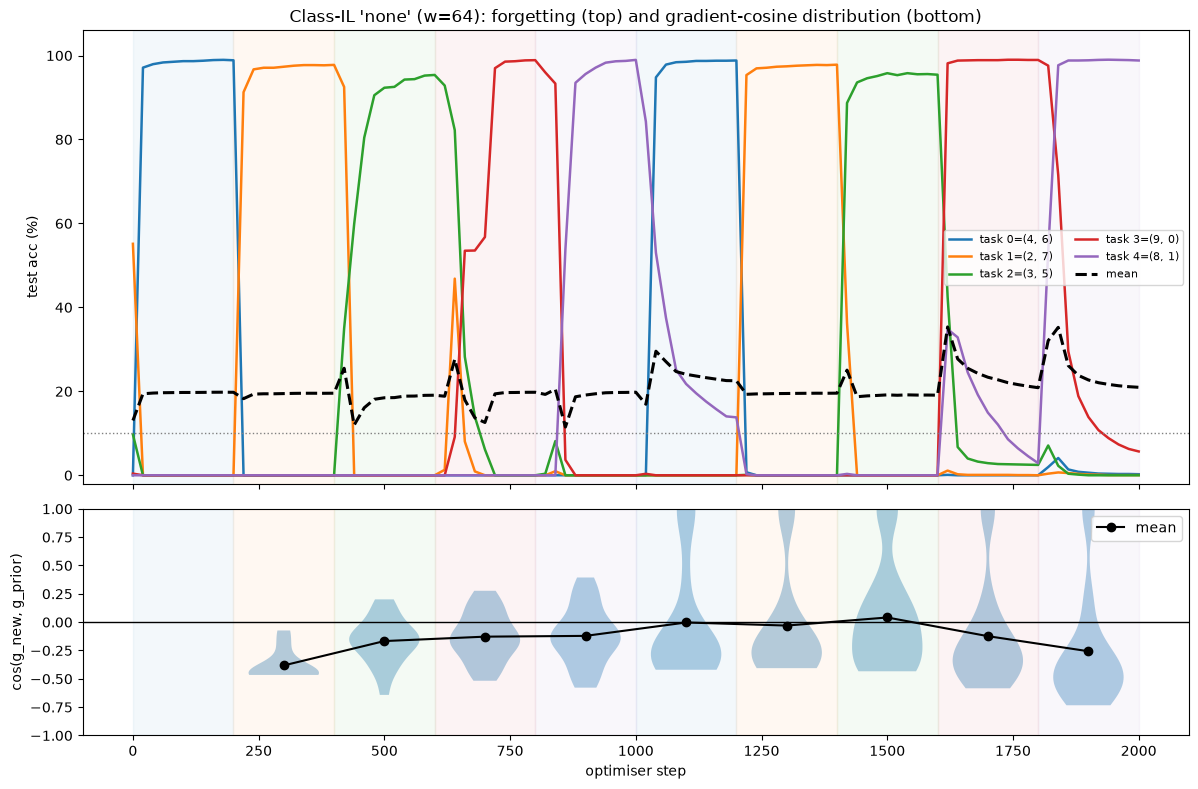

In [16]:
# Cell 15 — forgetting (top) + cosine DISTRIBUTION per task-phase (bottom)
sequence, iters_per_task, eval_every = [0, 1, 2, 3, 4] * 2, 200, 20
torch.manual_seed(0); model = make_mlp(hidden=(64,), out_dim=10)
acc_log, intf_log = run_classil_interference(model, sequence, iters_per_task, eval_every)

steps = [s for s, _ in acc_log]; accs = np.array([a for _, a in acc_log]) * 100
colors = plt.cm.tab10(np.arange(5)); bounds = [i * iters_per_task for i in range(len(sequence) + 1)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
for k in range(5):
    ax1.plot(steps, accs[:, k], color=colors[k], lw=1.8, label=f"task {k}={contexts[k]}")
ax1.plot(steps, accs.mean(1), "k--", lw=2.2, label="mean")
ax1.axhline(10, color="gray", ls=":", lw=1); ax1.set_ylim(-2, 106); ax1.set_ylabel("test acc (%)")
ax1.set_title("Class-IL 'none' (w=64): forgetting (top) and gradient-cosine distribution (bottom)")
ax1.legend(fontsize=8, loc="center right", ncol=2)

# gather every per-prior cosine into its task-phase, then draw a violin per phase
phase_cos = {}
for s, c, m, cosines in intf_log:
    ph = min(s // iters_per_task, len(sequence) - 1)
    phase_cos.setdefault(ph, []).extend(cosines)
phases = sorted(phase_cos)
centres = [p * iters_per_task + iters_per_task / 2 for p in phases]
ax2.axhline(0, color="k", lw=1)
vp = ax2.violinplot([phase_cos[p] for p in phases], positions=centres,
                    widths=iters_per_task * 0.7, showextrema=False)
for b in vp["bodies"]: b.set_facecolor("tab:blue"); b.set_alpha(0.35)
ax2.plot(centres, [np.mean(phase_cos[p]) for p in phases], "o-", color="k", lw=1.5, label="mean")
ax2.set_ylim(-1, 1); ax2.set_ylabel("cos(g_new, g_prior)"); ax2.set_xlabel("optimiser step"); ax2.legend(loc="upper right")

for ph, c in enumerate(sequence):
    for ax in (ax1, ax2): ax.axvspan(bounds[ph], bounds[ph + 1], color=colors[c], alpha=0.05)
plt.tight_layout(); plt.show()

### Replay
* Standard Experience Replay (ER)
* Store previous task examples to "replay" during next task training
* 20 examples per task (training set is 60k, so tiny percentage)
    * Batch size 128
    * Concatenate min(memory, 128)
    * So replay size increases from 20 > 40 > 80 > 100 > 120 > 128 > 128


In [17]:
# Cell 16 — Replay memory: store a few examples per class
class Memory:
    """Up to `per_class` examples per class (images + global digit labels)."""
    def __init__(self, per_class=20):
        self.per_class = per_class
        self.X, self.y = [], []
    def add_task(self, c):
        labels = train.targets.numpy()
        for digit in contexts[c]:
            pick = train_idx[c][labels[train_idx[c]] == digit][:self.per_class]
            self.X.append(_stack(train, pick))
            self.y.append(torch.tensor([int(digit)] * len(pick)).to(device))
    def sample(self, n):
        X, y = torch.cat(self.X), torch.cat(self.y)
        if len(y) <= n: return X, y
        sel = torch.randperm(len(y), device=device)[:n]
        return X[sel], y[sel]
    def __len__(self):
        return sum(len(t) for t in self.y)

In [18]:
# Cell 17 — Class-IL training with experience replay
def run_classil_replay(model, sequence, per_class=20, iters_per_task=200,
                       eval_every=20, optim='adam', lr=0.1, batch_size=128):
    model.to(device).train()
    if optim == 'sgd':
        opt = torch.optim.SGD(model.parameters(), lr=0.1)
    elif optim == 'adam':
        opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    mem = Memory(per_class=per_class)
    acc_log = [(0, [eval_task(model, k) for k in range(5)])]
    step = 0
    for ti, c in enumerate(sequence):
        loader = DataLoader(Subset(train, train_idx[c].tolist()), batch_size=batch_size, shuffle=True)
        it = iter(loader)
        for _ in range(iters_per_task):
            try: x, y = next(it)
            except StopIteration: it = iter(loader); x, y = next(it)
            x, y = x.to(device), y.to(device)
            if len(mem) > 0:                                  # mix in replayed examples
                xr, yr = mem.sample(batch_size)
                x, y = torch.cat([x, xr]), torch.cat([y, yr])
            opt.zero_grad(); loss_fn(model(x), y).backward(); opt.step()
            step += 1
            if step % eval_every == 0:
                acc_log.append((step, [eval_task(model, k) for k in range(5)]))
        mem.add_task(c)                                      # store this task after finishing it
    return acc_log, mem

final mean acc — none: 38.0%   replay(20/cls): 78.1%
buffer: 2000 images total (20/class)


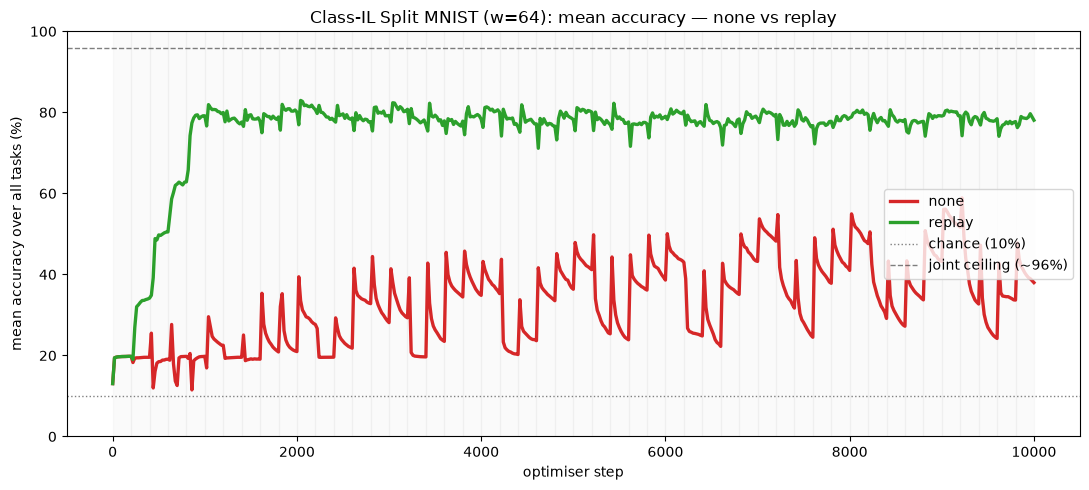

In [19]:
# Cell 18 — none vs replay; collect each method's mean-accuracy curve in `curves`
sequence, iters_per_task, eval_every = [0, 1, 2, 3, 4]*10, 200, 20
curves = {}                                                  # method -> (steps, mean_acc %)

torch.manual_seed(0)                                         # none baseline
m_none = make_mlp(hidden=(64,), out_dim=10)
log_none, _ = run_classil_interference(m_none, sequence, iters_per_task, eval_every)
s = [a for a, _ in log_none]; curves["none"] = (s, np.array([a for _, a in log_none]).mean(1) * 100)

torch.manual_seed(0)                                         # replay
m_rep = make_mlp(hidden=(64,), out_dim=10)
log_rep, mem = run_classil_replay(m_rep, sequence, per_class=20,
                                  iters_per_task=iters_per_task, eval_every=eval_every)
s = [a for a, _ in log_rep]; curves["replay"] = (s, np.array([a for _, a in log_rep]).mean(1) * 100)

print(f"final mean acc — none: {curves['none'][1][-1]:.1f}%   replay(20/cls): {curves['replay'][1][-1]:.1f}%")
print(f"buffer: {len(mem)} images total ({mem.per_class}/class)")

bounds = [i * iters_per_task for i in range(len(sequence) + 1)]
style = {"none": ("tab:red", "-"), "replay": ("tab:green", "-")}
fig, ax = plt.subplots(figsize=(11, 5))
for name, (st, mu) in curves.items():
    ax.plot(st, mu, color=style[name][0], ls=style[name][1], lw=2.4, label=name)
for ph, c in enumerate(sequence):
    ax.axvspan(bounds[ph], bounds[ph + 1], color="gray", alpha=0.04)
ax.axhline(10, color="gray", ls=":", lw=1, label="chance (10%)")
ax.axhline(96, color="black", ls="--", lw=1, alpha=0.5, label="joint ceiling (~96%)")
ax.set_xlabel("optimiser step"); ax.set_ylabel("mean accuracy over all tasks (%)"); ax.set_ylim(0, 100)
ax.set_title("Class-IL Split MNIST (w=64): mean accuracy — none vs replay")
ax.legend(loc="center right"); plt.tight_layout(); plt.show()

#### Add per task accuracies to plot

In [20]:
# # Cell 19 — none vs replay: bold mean + thin per-task lines
# # Reuses log_none, log_rep from Cell 18 (re-run Cell 18 first if not in memory).
# sequence = [0, 1, 2, 3, 4]; iters_per_task = 200
# bounds = [i * iters_per_task for i in range(len(sequence) + 1)]

# s_none = [a for a, _ in log_none]; A_none = np.array([a for _, a in log_none]) * 100   # [n,5]
# s_rep  = [a for a, _ in log_rep ]; A_rep  = np.array([a for _, a in log_rep ]) * 100

# fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharey=True)
# panels = [("none", s_none, A_none, "tab:red", axes[0]),
#           ("replay (20/class)", s_rep, A_rep, "tab:green", axes[1])]
# tcolors = plt.cm.tab10(np.arange(5))

# for title, st, A, mean_color, ax in panels:
#     for k in range(5):                                   # thin per-task lines
#         ax.plot(st, A[:, k], color=tcolors[k], lw=1.0, alpha=0.55, label=f"task {k}={contexts[k]}")
#     ax.plot(st, A.mean(1), color=mean_color, lw=3.0, label="mean")   # bold mean
#     for ph, c in enumerate(sequence):
#         ax.axvspan(bounds[ph], bounds[ph + 1], color="gray", alpha=0.04)
#     ax.axhline(10, color="gray", ls=":", lw=1)
#     ax.set_title(title); ax.set_xlabel("optimiser step"); ax.set_ylim(-2, 104)
# axes[0].set_ylabel("test accuracy (%)")
# axes[1].legend(loc="lower right", fontsize=8, ncol=2)
# fig.suptitle("Per-task accuracy (thin) and mean (bold): none vs replay", y=1.02)
# plt.tight_layout(); plt.show()

### Consolidate training code

In [21]:
# Cell 20 — One trainer + pluggable strategies. Designate as src/trainer.py later;
# keep as a cell for now so it's immediately usable.
class Strategy:
    """Base strategy = 'none' (plain sequential training). All hooks are no-ops."""
    def before_task(self, model, task_id):       pass
    def augment_batch(self, x, y):                return x, y          # batch contents
    def extra_loss(self, model, x, y):            return 0.0           # extra loss term
    def after_task(self, model, task_id):         pass                 # end-of-task update

class ReplayStrategy(Strategy):
    def __init__(self, per_class=20):
        self.mem = Memory(per_class=per_class)
    def augment_batch(self, x, y):
        if len(self.mem) == 0: return x, y
        xr, yr = self.mem.sample(len(x))                                # match current batch size
        return torch.cat([x, xr]), torch.cat([y, yr])
    def after_task(self, model, task_id):
        self.mem.add_task(task_id)

def run_classil(model, sequence, strategy=None, iters_per_task=200,
                eval_every=20, optim='adam', lr=0.1, batch_size=128):
    """Class-IL sequential training. Behaviour set entirely by `strategy`."""
    strategy = strategy or Strategy()
    model.to(device).train()
    if optim == 'sgd':
        opt = torch.optim.SGD(model.parameters(), lr=0.1)
    elif optim == 'adam':
        opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    acc_log = [(0, [eval_task(model, k) for k in range(5)])]
    step = 0
    for ti, c in enumerate(sequence):
        strategy.before_task(model, c)
        loader = DataLoader(Subset(train, train_idx[c].tolist()), batch_size=batch_size, shuffle=True)
        it = iter(loader)
        for _ in range(iters_per_task):
            try: x, y = next(it)
            except StopIteration: it = iter(loader); x, y = next(it)
            x, y = x.to(device), y.to(device)
            x, y = strategy.augment_batch(x, y)
            opt.zero_grad()
            loss = loss_fn(model(x), y) + strategy.extra_loss(model, x, y)
            loss.backward(); opt.step()
            step += 1
            if step % eval_every == 0:
                acc_log.append((step, [eval_task(model, k) for k in range(5)]))
        strategy.after_task(model, c)
    return acc_log

In [22]:
# Cell 21 — Confirm the unified trainer matches prior results (1 pass), and seed `curves`
sequence = [0, 1, 2, 3, 4]
curves = {}

torch.manual_seed(0)
m = make_mlp(hidden=(64,), out_dim=10)
log = run_classil(m, sequence, strategy=Strategy())                    # 'none'
curves["none"] = ([s for s, _ in log], np.array([a for _, a in log]).mean(1) * 100)

torch.manual_seed(0)
m = make_mlp(hidden=(64,), out_dim=10)
log = run_classil(m, sequence, strategy=ReplayStrategy(per_class=20))  # replay
curves["replay"] = ([s for s, _ in log], np.array([a for _, a in log]).mean(1) * 100)

print(f"none:   {curves['none'][1][-1]:.1f}%   (expect ~21.6)")
print(f"replay: {curves['replay'][1][-1]:.1f}%   (expect ~79)")

none:   19.8%   (expect ~21.6)
replay: 79.0%   (expect ~79)


#### EWC - Eastic Weight Consolidation

#### EWC

Parameters:
* lambda=100, penalty strength, how hard to fix important weights
    * increase if no different from baseline
    * decrease if model locks (no new learning)
* fischer_n=500, sample size for fischer matrix calculation

In [23]:
# EWCStrategy — plugs into run_classil via extra_loss + after_task
class EWCStrategy(Strategy):
    def __init__(self, lam=100.0, fisher_n=500):
        self.lam = lam; self.fisher_n = fisher_n
        self.tasks = []                                   # list of (theta_star, fisher) per finished task

    def extra_loss(self, model, x, y):                    # the spring penalty
        if not self.tasks: return 0.0
        params = dict(model.named_parameters()); pen = 0.0
        for theta_star, fisher in self.tasks:
            for n, p in params.items():
                pen = pen + (fisher[n] * (p - theta_star[n]) ** 2).sum()
        return self.lam * pen

    def after_task(self, model, task_id):                 # measure importance after the task
        theta_star = {n: p.detach().clone() for n, p in model.named_parameters()}
        fisher     = {n: torch.zeros_like(p) for n, p in model.named_parameters()}
        idxs = train_idx[task_id][:self.fisher_n]
        X = _stack(train, idxs)
        Y = torch.tensor([train[i][1] for i in idxs]).to(device)
        for i in range(len(Y)):                           # empirical Fisher = mean squared per-sample grad
            model.zero_grad(); loss_fn(model(X[i:i+1]), Y[i:i+1]).backward()
            for n, p in model.named_parameters():
                if p.grad is not None: fisher[n] += p.grad.detach() ** 2
        for n in fisher: fisher[n] /= len(Y)
        model.zero_grad()
        self.tasks.append((theta_star, fisher))           # kept for the importance plots later

final mean accuracy (1 pass):
  none   : 21.0%
  replay : 80.0%
  ewc    : 53.6%


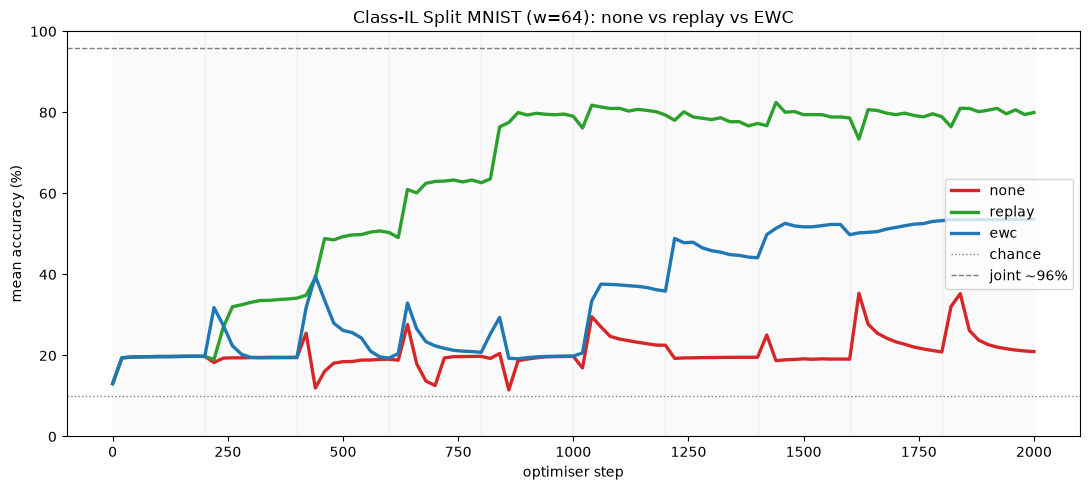

In [24]:
# none vs replay vs EWC — same config, keep handles for the importance analysis
sequence = [0, 1, 2, 3, 4]*2; curves = {}

torch.manual_seed(0); m_none = make_mlp(hidden=(64,), out_dim=10)
log = run_classil(m_none, sequence, strategy=Strategy())
curves["none"] = ([s for s, _ in log], np.array([a for _, a in log]).mean(1) * 100)

torch.manual_seed(0); m_rep = make_mlp(hidden=(64,), out_dim=10)
log = run_classil(m_rep, sequence, strategy=ReplayStrategy(per_class=20))
curves["replay"] = ([s for s, _ in log], np.array([a for _, a in log]).mean(1) * 100)

torch.manual_seed(0); m_ewc = make_mlp(hidden=(64,), out_dim=10)
strat_ewc = EWCStrategy(lam=10000.0, fisher_n=500)          # keep this instance
log = run_classil(m_ewc, sequence, strategy=strat_ewc)
curves["ewc"] = ([s for s, _ in log], np.array([a for _, a in log]).mean(1) * 100)

print("final mean accuracy (1 pass):")
for n in ["none", "replay", "ewc"]: print(f"  {n:7s}: {curves[n][1][-1]:.1f}%")

bounds = [i * 200 for i in range(len(sequence) + 1)]
style = {"none": "tab:red", "replay": "tab:green", "ewc": "tab:blue"}
fig, ax = plt.subplots(figsize=(11, 5))
for n in ["none", "replay", "ewc"]:
    st, mu = curves[n]; ax.plot(st, mu, color=style[n], lw=2.4, label=n)
for ph, c in enumerate(sequence): ax.axvspan(bounds[ph], bounds[ph + 1], color="gray", alpha=0.04)
ax.axhline(10, color="gray", ls=":", lw=1, label="chance"); ax.axhline(96, color="k", ls="--", lw=1, alpha=.5, label="joint ~96%")
ax.set_xlabel("optimiser step"); ax.set_ylabel("mean accuracy (%)"); ax.set_ylim(0, 100)
ax.set_title("Class-IL Split MNIST (w=64): none vs replay vs EWC"); ax.legend(loc="center right")
plt.tight_layout(); plt.show()

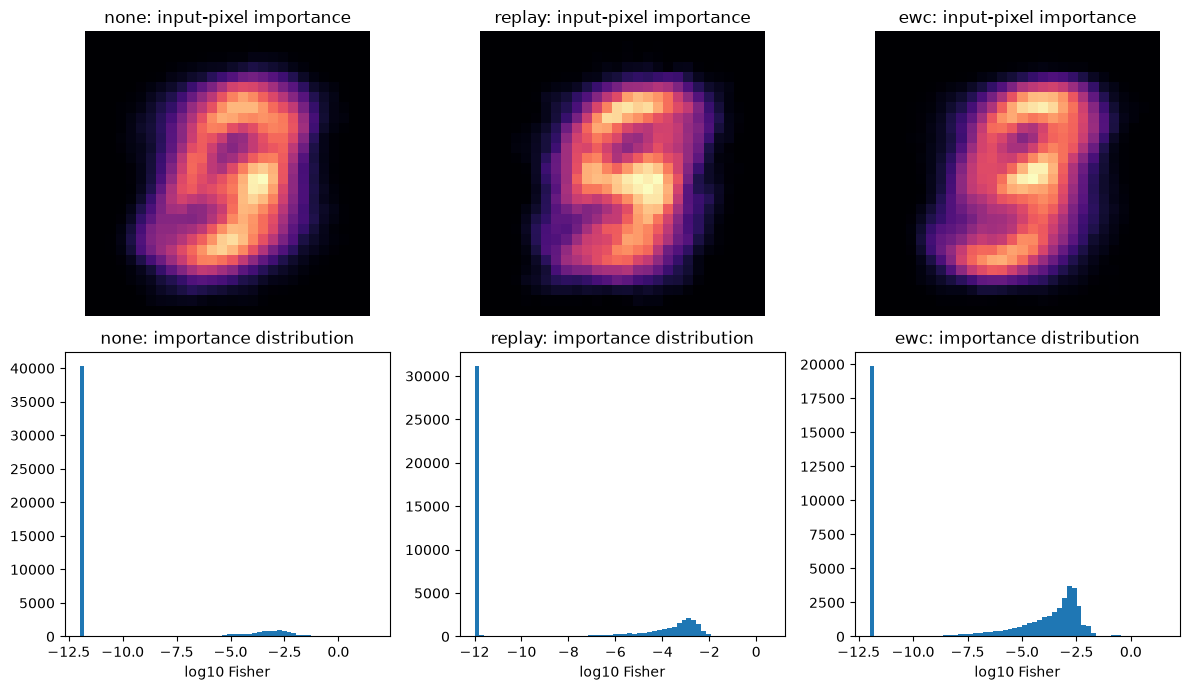

In [25]:
# Fisher importance maps + distributions for the three final models
def total_fisher(model, n_per_task=200):
    fisher = {n: torch.zeros_like(p) for n, p in model.named_parameters()}; count = 0
    for c in range(5):
        idxs = train_idx[c][:n_per_task]
        X = _stack(train, idxs); Y = torch.tensor([train[i][1] for i in idxs]).to(device)
        for i in range(len(Y)):
            model.zero_grad(); loss_fn(model(X[i:i+1]), Y[i:i+1]).backward()
            for n, p in model.named_parameters():
                if p.grad is not None: fisher[n] += p.grad.detach() ** 2
            count += 1
    model.zero_grad()
    for n in fisher: fisher[n] /= count
    return fisher

models  = {"none": m_none, "replay": m_rep, "ewc": m_ewc}
fishers = {name: total_fisher(m) for name, m in models.items()}
first   = [n for n, _ in m_none.named_parameters() if "weight" in n][0]   # input-layer weights

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for j, (name, F) in enumerate(fishers.items()):
    imp = F[first].sum(0).reshape(28, 28).cpu().numpy()                   # importance per input pixel
    axes[0, j].imshow(imp, cmap="magma"); axes[0, j].set_title(f"{name}: input-pixel importance"); axes[0, j].axis("off")
    allw = torch.cat([v.flatten() for v in F.values()]).cpu().numpy()
    axes[1, j].hist(np.log10(allw + 1e-12), bins=60)
    axes[1, j].set_title(f"{name}: importance distribution"); axes[1, j].set_xlabel("log10 Fisher")
plt.tight_layout(); plt.show()

  lambda=     0: final mean acc 19.8%
  lambda=     1: final mean acc 19.8%
  lambda=    10: final mean acc 19.8%
  lambda=   100: final mean acc 20.8%
  lambda=  1000: final mean acc 19.8%
  lambda= 10000: final mean acc 19.8%


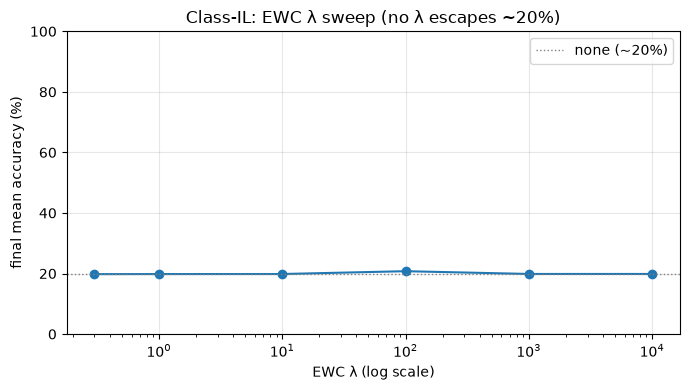

In [26]:
# EWC lambda sweep — trace the retention/plasticity trade-off
lams = [0, 1, 10, 100, 1000, 10000]
ewc_sweep = {}
for lam in lams:
    torch.manual_seed(0); m = make_mlp(hidden=(64,), out_dim=10)
    strat = EWCStrategy(lam=float(lam), fisher_n=500) if lam > 0 else Strategy()
    log = run_classil(m, [0, 1, 2, 3, 4], strategy=strat)
    ewc_sweep[lam] = np.array([a for _, a in log]).mean(1)[-1] * 100
    print(f"  lambda={lam:6}: final mean acc {ewc_sweep[lam]:.1f}%")

plt.figure(figsize=(7, 4))
plt.plot([max(l, 0.3) for l in lams], [ewc_sweep[l] for l in lams], "o-")   # 0 shown at 0.3 for log axis
plt.xscale("log"); plt.axhline(20, color="gray", ls=":", lw=1, label="none (~20%)")
plt.xlabel("EWC λ (log scale)"); plt.ylabel("final mean accuracy (%)"); plt.ylim(0, 100)
plt.title("Class-IL: EWC λ sweep (no λ escapes ~20%)"); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### EBM


In [34]:
# EBM: Equilibrium Propagation (supervisor's approach, cleaned for convergence)
def ebm_init(in_dim=784, hidden=256, out_dim=10, seed=0):
    g = torch.Generator(device=device).manual_seed(seed)
    W1 = (torch.randn(in_dim, hidden, generator=g, device=device) / in_dim**0.5).requires_grad_(True)  # Xavier
    W2 = (torch.randn(hidden, out_dim, generator=g, device=device) / hidden**0.5).requires_grad_(True)
    return W1, W2

def ebm_energy(x, h, y, W1, W2):
    """Scalar energy for the batch; activities h,y are the variables, W1,W2 the weights."""
    state = 0.5 * (h**2).sum() + 0.5 * (y**2).sum()
    align = (h * (x @ W1)).sum() + (y * (torch.tanh(h) @ W2)).sum()
    return state - align

# def ebm_settle(x, W1, W2, target=None, beta=0.0, steps=20, dt=0.5, lazy=False):
#     """Relax (h,y) to an energy minimum; if target given, add a beta*hinge nudge on y."""
#     x = x.reshape(x.size(0), -1)
#     h = torch.zeros(x.size(0), W1.size(1), device=device, requires_grad=True)
#     y = torch.zeros(x.size(0), W2.size(1), device=device, requires_grad=True)
#     active = 1.0
#     if target is not None and lazy:                       # nudge only margin-violators
#         active = ((torch.clamp(1.0 - target * y, min=0).sum(1)) > 0).float().unsqueeze(1)
#     for _ in range(steps):
#         E = ebm_energy(x, h, y, W1, W2)
#         if target is not None:
#             E = E + beta * (active * torch.clamp(1.0 - target * y, min=0)).sum()
#         gh, gy = torch.autograd.grad(E, [h, y])
#         h.data -= dt * gh; y.data -= dt * gy
#     return h.detach(), y.detach()

def ebm_settle(x, W1, W2, target=None, beta=0.0, steps=20, dt=0.5, lazy=False):
    """Relax (h,y) to an energy minimum; if target given, add a beta*hinge nudge on y."""
    
    # Force PyTorch to track gradients for this block, even if called inside no_grad()
    with torch.enable_grad(): 
        x = x.reshape(x.size(0), -1)
        h = torch.zeros(x.size(0), W1.size(1), device=device, requires_grad=True)
        y = torch.zeros(x.size(0), W2.size(1), device=device, requires_grad=True)
        
        active = 1.0
        if target is not None and lazy:
            active = ((torch.clamp(1.0 - target * y, min=0).sum(1)) > 0).float().unsqueeze(1)
            
        for _ in range(steps):
            E = ebm_energy(x, h, y, W1, W2)
            if target is not None:
                E = E + beta * (active * torch.clamp(1.0 - target * y, min=0)).sum()
            gh, gy = torch.autograd.grad(E, [h, y])
            
            # Update states using the gradients
            h.data -= dt * gh
            y.data -= dt * gy
            
    return h.detach(), y.detach()

# def ebm_step(x, target, W1, W2, opt, beta=0.5, steps=20, dt=0.5, lazy=False, clip=5.0):
#     """One EqProp weight update on a batch. target in {-1,+1}^[B,10]."""
#     h_f, y_f = ebm_settle(x, W1, W2, steps=steps, dt=dt)                  # free phase
#     h_n, y_n = ebm_settle(x, W1, W2, target, beta, steps, dt, lazy)      # nudged phase
#     opt.zero_grad()
#     gW1_f, gW2_f = torch.autograd.grad(ebm_energy(x, h_f, y_f, W1, W2), [W1, W2])
#     gW1_n, gW2_n = torch.autograd.grad(ebm_energy(x, h_n, y_n, W1, W2), [W1, W2])
#     W1.grad = (gW1_n - gW1_f) / (beta * x.size(0))
#     W2.grad = (gW2_n - gW2_f) / (beta * x.size(0))
#     torch.nn.utils.clip_grad_norm_([W1, W2], max_norm=clip)
#     opt.step()
#     return (y_f.argmax(1) == target.argmax(1)).float().mean().item()

def ebm_step(x, target, W1, W2, opt, beta=0.5, steps=20, dt=0.5, lazy=False, clip=5.0):
    """One EqProp weight update on a batch. target in {-1,+1}^[B,10]."""
    
    # ADD THIS LINE: Flatten x right at the entry point of the step
    x = x.reshape(x.size(0), -1) 
    
    h_f, y_f = ebm_settle(x, W1, W2, steps=steps, dt=dt)                  # free phase
    h_n, y_n = ebm_settle(x, W1, W2, target, beta, steps, dt, lazy)      # nudged phase
    
    opt.zero_grad()
    
    # Now x is [128, 784], so x @ W1 inside ebm_energy will work perfectly
    gW1_f, gW2_f = torch.autograd.grad(ebm_energy(x, h_f, y_f, W1, W2), [W1, W2])
    gW1_n, gW2_n = torch.autograd.grad(ebm_energy(x, h_n, y_n, W1, W2), [W1, W2])
    
    W1.grad = (gW1_n - gW1_f) / (beta * x.size(0))
    W2.grad = (gW2_n - gW2_f) / (beta * x.size(0))
    
    torch.nn.utils.clip_grad_norm_([W1, W2], max_norm=clip)
    opt.step()
    
    return (y_f.argmax(1) == target.argmax(1)).float().mean().item()


In [ ]:
# Sanity: can the EBM learn all 10 digits at once?
W1, W2 = ebm_init(hidden=256, seed=0)
opt = torch.optim.SGD([W1, W2], lr=0.5)
loader = DataLoader(train, batch_size=128, shuffle=True)
for ep in range(10):
    accs = []
    for bi, (x, y) in enumerate(loader):
        x, y = x.to(device), y.to(device)
        target = torch.full((x.size(0), 10), -1.0, device=device); target.scatter_(1, y.unsqueeze(1), 1.0)
        accs.append(ebm_step(x, target, W1, W2, opt, beta=0.5, steps=20, dt=0.5, lazy=False))
        if bi % 100 == 0:
            # diagnostics from your supervisor's log
            with torch.no_grad():
                h_f, _ = ebm_settle(x, W1, W2, steps=20, dt=0.5)
                sat = (torch.tanh(h_f).abs() > 0.95).float().mean().item() * 100
            print(f"ep{ep} b{bi:4d}: acc {np.mean(accs[-50:])*100:5.1f}% | saturation {sat:4.1f}% | |W1grad|~ok")
    print(f"epoch {ep}: mean batch acc {np.mean(accs)*100:.1f}%\n")

ep0 b   0: acc  12.5% | saturation  6.5% | |W1grad|~ok
ep0 b 100: acc  13.2% | saturation 60.4% | |W1grad|~ok
ep0 b 200: acc  21.8% | saturation 90.3% | |W1grad|~ok
ep0 b 300: acc  28.0% | saturation 91.9% | |W1grad|~ok
ep0 b 400: acc  26.5% | saturation 98.2% | |W1grad|~ok
epoch 0: mean batch acc 22.2%

ep1 b   0: acc  17.2% | saturation 98.4% | |W1grad|~ok
ep1 b 100: acc  30.5% | saturation 98.7% | |W1grad|~ok
ep1 b 200: acc  30.9% | saturation 99.2% | |W1grad|~ok
ep1 b 300: acc  34.6% | saturation 99.0% | |W1grad|~ok
ep1 b 400: acc  33.7% | saturation 99.3% | |W1grad|~ok
epoch 1: mean batch acc 31.0%

ep2 b   0: acc  31.2% | saturation 99.5% | |W1grad|~ok
ep2 b 100: acc  27.8% | saturation 99.7% | |W1grad|~ok
ep2 b 200: acc  25.5% | saturation 99.7% | |W1grad|~ok
ep2 b 300: acc  29.1% | saturation 99.7% | |W1grad|~ok
ep2 b 400: acc  28.6% | saturation 99.8% | |W1grad|~ok
epoch 2: mean batch acc 28.1%

ep3 b   0: acc  20.3% | saturation 99.9% | |W1grad|~ok
ep3 b 100: acc  25.8% | sat

In [36]:
def ebm_eval_task(W1, W2, c, n=500, steps=20, dt=0.5):
    idx = test_idx[c][:n]
    X = _stack(test, idx)
    ytrue = torch.tensor([test[i][1] for i in idx], device=device)
    _, y = ebm_settle(X, W1, W2, steps=steps, dt=dt)          # free-phase prediction
    return (y.argmax(1) == ytrue).float().mean().item()

def run_classil_ebm(sequence, hidden=256, iters_per_task=200, eval_every=40,
                    lr=0.5, beta=0.5, steps=20, dt=0.5, lazy=False, batch_size=128, seed=0):
    W1, W2 = ebm_init(hidden=hidden, seed=seed)
    opt = torch.optim.SGD([W1, W2], lr=lr)
    acc_log = [(0, [ebm_eval_task(W1, W2, k, steps=steps, dt=dt) for k in range(5)])]
    step = 0
    for c in sequence:
        loader = DataLoader(Subset(train, train_idx[c].tolist()), batch_size=batch_size, shuffle=True)
        it = iter(loader)
        for _ in range(iters_per_task):
            try: x, y = next(it)
            except StopIteration: it = iter(loader); x, y = next(it)
            x, y = x.to(device), y.to(device)
            target = torch.full((x.size(0), 10), -1.0, device=device); target.scatter_(1, y.unsqueeze(1), 1.0)
            ebm_step(x, target, W1, W2, opt, beta=beta, steps=steps, dt=dt, lazy=lazy)
            step += 1
            if step % eval_every == 0:
                acc_log.append((step, [ebm_eval_task(W1, W2, k, steps=steps, dt=dt) for k in range(5)]))
    return acc_log, (W1, W2)

# run and slot into the existing `curves` comparison
log_ebm, _ = run_classil_ebm([0, 1, 2, 3, 4])
curves["ebm"] = ([s for s, _ in log_ebm], np.array([a for _, a in log_ebm]).mean(1) * 100)
print(f"EBM final mean acc: {curves['ebm'][1][-1]:.1f}%")

EBM final mean acc: 10.8%


In [37]:
# Cell 7 — Stage 2 engine: sequential trainer with all-pair logging (shared 2-unit head)
import numpy as np
from torch.utils.data import Subset, DataLoader
import torch.nn as nn

# Build each context's TEST set once (within-pair labels: pair[0]->0, pair[1]->1)
def build_context_testsets():
    X, y = {}, {}
    for c in range(5):
        idx = test_idx[c]
        X[c] = torch.stack([test[i][0] for i in idx]).to(device)
        yg = torch.tensor([test[i][1] for i in idx])
        y[c] = (yg == contexts[c][1]).long().to(device)
    return X, y

Xtest_c, ytest_c = build_context_testsets()
print("per-context test sizes:", {c: len(ytest_c[c]) for c in range(5)})

@torch.no_grad()
def eval_pair(model, c):
    """Accuracy on context c's test set, via the shared 2-unit head."""
    model.eval()
    acc = (model(Xtest_c[c]).argmax(1) == ytest_c[c]).float().mean().item()
    model.train()
    return acc

def run_sequential(model, sequence, iters_per_task=200, eval_every=20,
                   lr=1e-3, batch_size=128):
    """Train `model` on each context in `sequence`, one at a time (shared 2-unit head,
    within-pair labels). Logs accuracy on ALL 5 pairs every `eval_every` steps.
    One optimiser across the whole run (no reset).
    Reproducibility: seed once before building the model (see Cell 8)."""
    model.to(device).train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    log = [{"step": 0, "phase": -1, "train_c": None,           # snapshot before any training
            "accs": [eval_pair(model, k) for k in range(5)]}]
    step = 0
    for phase, c in enumerate(sequence):
        loader = DataLoader(Subset(train, train_idx[c].tolist()),
                            batch_size=batch_size, shuffle=True)
        it = iter(loader)
        for _ in range(iters_per_task):
            try:    x, yg = next(it)
            except StopIteration:
                    it = iter(loader); x, yg = next(it)
            x = x.to(device)
            y = (yg == contexts[c][1]).long().to(device)        # within-pair labels
            opt.zero_grad(); loss_fn(model(x), y).backward(); opt.step()
            step += 1
            if step % eval_every == 0:
                log.append({"step": step, "phase": phase, "train_c": c,
                            "accs": [eval_pair(model, k) for k in range(5)]})
    return log

per-context test sizes: {0: 1940, 1: 2060, 2: 1902, 3: 1989, 4: 2109}
